In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform

In [3]:
def f(a):
    return np.sqrt(1+np.sqrt(1-a**2)/2)

In [5]:
a = np.random.uniform(0,1,1000)
gauss_m = norm(1, 0.2)

In [6]:
M = gauss_m.rvs(1000)

In [7]:
M_irr = M*f(a)

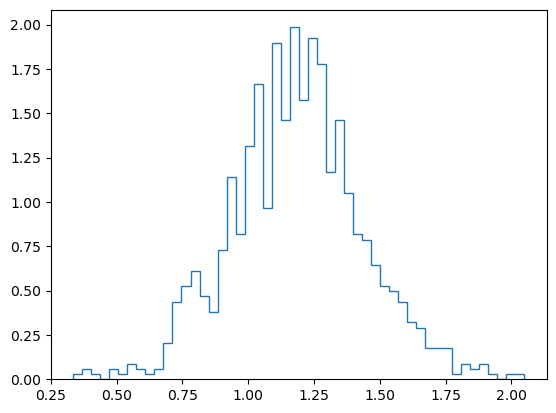

In [10]:
plt.hist(M_irr, bins=50, density=True, histtype='step')
plt.show()

### Freedman-Diaconis

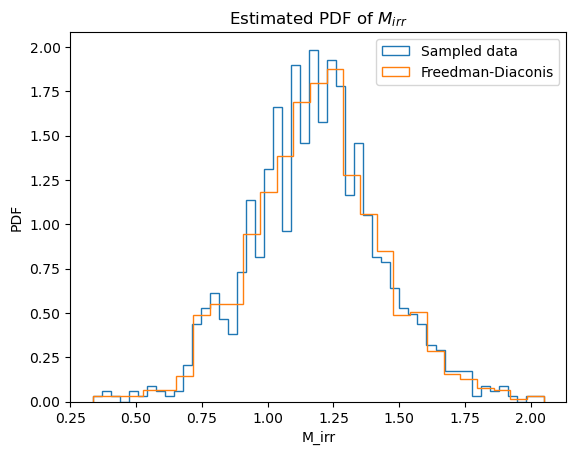

In [23]:
q25, q75 = np.percentile(M_irr, [25,75])
iqr = q75 - q25
bin_width = 2*iqr*len(M_irr)**(-1/3)

bins = int((M_irr.max() - M_irr.min())/ bin_width)

plt.hist(M_irr, bins=50, density=True, histtype='step', label='Sampled data')
plt.hist(M_irr, bins=bins, density=True, histtype='step', label='Freedman-Diaconis')

plt.xlabel('M_irr')
plt.ylabel('PDF')
plt.title('Estimated PDF of $M_{irr}$')
plt.legend()
plt.show()

### KDE

In [26]:
from scipy.stats import gaussian_kde, ks_2samp

In [16]:
kde = gaussian_kde(M_irr)

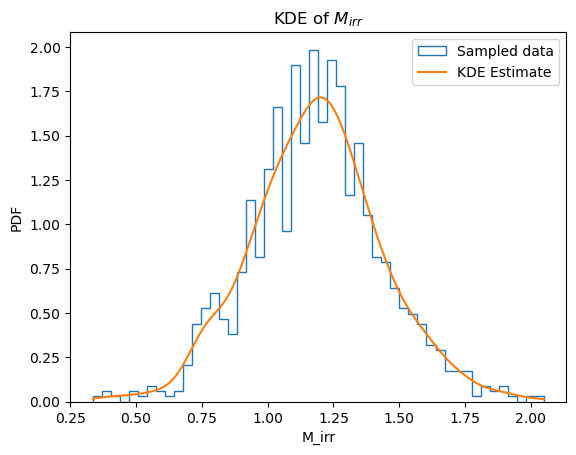

In [21]:
xgrid = np.linspace(M_irr.min(), M_irr.max(), 1000)
pdf_vals = kde(xgrid)

plt.hist(M_irr, bins=50, density=True, histtype='step', label='Sampled data')
plt.plot(xgrid, pdf_vals, label = 'KDE Estimate')
plt.xlabel('M_irr')
plt.ylabel('PDF')
plt.title('KDE of $M_{irr}$')
plt.legend()
plt.show()

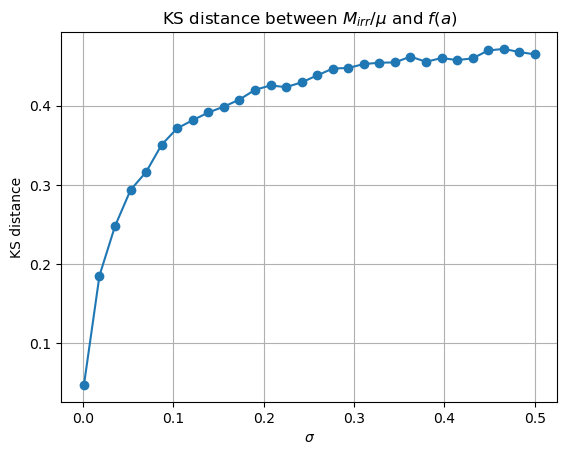

In [27]:
mu = 1.0
sigmas = np.linspace(0.001, 0.5, 30)
ks_values = []

N = 10000

for sigma in sigmas:
    a = np.random.uniform(0,1,N)
    M = norm(mu, sigma).rvs(N)

    M_irr = M*f(a)

    X = M_irr / mu
    Y = f(a)

    ks_stat, _ = ks_2samp(X,Y)
    ks_values.append(ks_stat)

plt.plot(sigmas, ks_values, marker='o')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS distance')
plt.title('KS distance between $M_{irr}/\mu$ and $f(a)$')
plt.grid()
plt.show()

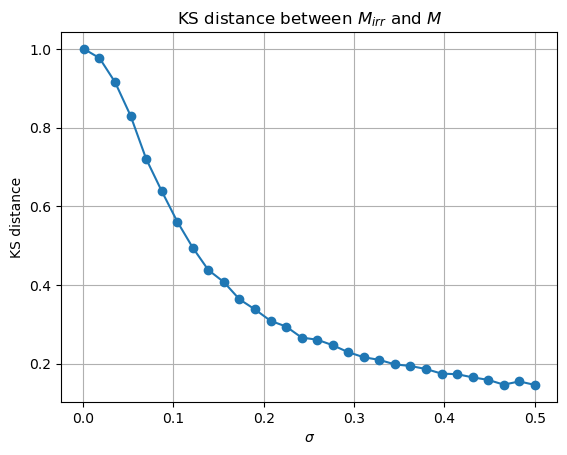

In [29]:
ks_values = []

for sigma in sigmas:
    a = np.random.uniform(0,1,N)
    M = norm(mu, sigma).rvs(N)

    M_irr = M*f(a)

    ks_stat, _ = ks_2samp(M,M_irr)
    ks_values.append(ks_stat)

plt.plot(sigmas, ks_values, marker='o')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS distance')
plt.title('KS distance between $M_{irr}$ and $M$')
plt.grid()
plt.show()